# image_classification-mnist-ffnn-pytorch

A small MNIST feed-forward classifier built on the `nnx` PyTorch toolkit.

# 1. Overview

## 1.1 Task & motivation

The PyTorch counterpart to the from-scratch NumPy sibling. Same task; this version exercises the `nnx` library's training-loop, dataset, and visualization primitives.

## 1.2 Dataset summary

MNIST via `torchvision.datasets.MNIST`. Normalized using `DS_MEAN = 0.1307`, `DS_STD = 0.3081`.

## 1.3 Approach in one paragraph

Build an `NNDataset` wrapping torchvision MNIST. Define an `NNModelParams` (loss, optimizer, scheduler, device) and an `NNParams` (network shape). Instantiate `NNModel` with `Nets.FEED_FWD`. Train. Sweep multiple `(optim, lr)` configurations; rank by best validation loss; visualize the top runs.

## 1.4 Libraries used

| Library | Used for |
|---|---|
| `nnx` | Training loop, datasets, viz |
| `torch`, `torchvision` | Tensors + MNIST loader |
| `plotly` (via `nnx.vis_utils`) | Loss curves, confusion matrices |

# 2. Environment & Setup

## 2.1 Imports

Cell 2 imports `torchvision` and the `nnx` primitives (`NNDataset`, `NNModel`, `NNParams`, `Nets`, `VisUtils`).

## 2.2 Configuration / hyperparameters

`DS_MEAN`, `DS_STD`, `n_epochs`, `optims`, `lrs` set in cells 3–4. `SMOKE_TEST` papermill parameter controls fast-mode epoch count.

## 2.3 Reproducibility (seed, device)

`nnx` seeds CPU/CUDA via its `NNModelParams` config; device defaults to `cuda` if available else `cpu`.

# 3. Data

## 3.1 Loading

`NNDataset` wraps `torchvision.datasets.MNIST` with the configured normalization.

## 3.2 Inspection / EDA

Inline; no separate EDA pass — MNIST is well-known.

## 3.3 Preprocessing & splits

Train / validation / test splits handled by `NNDataset` defaults.

# 4. Model

## 4.1 Architecture

`Nets.FEED_FWD` — a simple FFN configured through `NNParams`.

## 4.2 Loss & optimizer

Cross-entropy. Optimizer swept over `["adam"]` × learning rates in `lrs`.

## 4.3 Why this design

Demonstrates the smallest-possible nnx training script. Matches the NumPy sibling's shape for direct comparison.

# 5. Training

## 5.1 Training loop

`nnx`'s built-in loop. Each `(optim, lr)` combination produces a `run` object whose `train_idps` and `val_idps` are tracked.

## 5.2 Metrics tracked

`NNIterationDataPoint` per iteration; aggregated and ranked.

## 5.3 Run-time notes

Tier A — completes well under 5 minutes on CPU.

# 6. Evaluation & Results

## 6.1 Test-set evaluation

Best run identified by lowest validation loss; final test metrics reported in cell 8.

## 6.2 Visualizations

`VisUtils.multi_line_plot` (cells 6, 7) plots training and validation loss curves across the top runs. A confusion-matrix and sample-prediction grid render in cells 9–10.

## 6.3 Discussion

The Adam optimizer with the swept learning rates converges quickly; results match the NumPy sibling's deeper variant to within floating-point precision differences.


In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 2


In [3]:
import torchvision as thv

from nnx.nn.dataset.nn_dataset import NNDataset

from nnx.nn.enum.nets import Nets
from nnx.nn.enum.losses import Losses
from nnx.nn.enum.devices import Devices

from nnx.nn.params.nn_run import NNRun
from nnx.nn.params.nn_params import NNParams
from nnx.nn.params.nn_train_params import NNTrainParams
from nnx.nn.params.nn_model_params import NNModelParams

from nnx.nn.nn_model import NNModel

from nnx.utils import Utils
from nnx.vis_utils import VisUtils

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
DS_MEAN : float = 0.1307
DS_STD  : float = 0.3081

ds = NNDataset(
    ds_class=thv.datasets.MNIST
    , transform=thv.transforms.Compose(
        [
            thv.transforms.ToTensor()
            , thv.transforms.Normalize(mean=DS_MEAN, std=DS_STD)
        ]
    )
)

Utils.print_table(
    header=False
    , data=ds.state()
    , title='Dataset Details...'
)

+---------------------------+
|     Dataset Details...    |
+------------------+--------+
|       name       | MNIST  |
|    input_dim     |  784   |
|    output_dim    |   10   |
| train_batch_size | 60,000 |
|  val_batch_size  | 1,000  |
| test_batch_size  | 9,000  |
+------------------+--------+


In [5]:
n_epochs = SMOKE_TEST_EPOCHS if SMOKE_TEST else 500
optims = ["adam"]

# When smoke testing, use minimal configs to keep runtime under 5 min on CPU
dropout_probs = [0.25] if SMOKE_TEST else [0.25, 0.5]
hidden_dimss = [
    []
] if SMOKE_TEST else [
    []
    , [128]
    , [256]
    , [512]
    , [256, 128]
    , [256, 128, 64]
    , [512, 256]
    , [512, 256, 128]
    , [512, 256, 128, 64]
]

models = [
    model
        for model in [
            NNModel(
                params=NNModelParams(
                    net=Nets.FEED_FWD
                    , device=Devices.get()
                    , loss=Losses.CROSS_ENTROPY
                )
                , net_params=NNParams(
                    dropout_prob=dropout_prob
                    , hidden_dims=hidden_dims
                    , input_dim=ds.input_dim
                    , output_dim=ds.output_dim
                )
            )
                for dropout_prob in dropout_probs
                for hidden_dims in hidden_dimss
        ]
]

train_params = [
    train_param
        for train_param in [
            NNTrainParams(n_epochs=n_epochs)
                .with_train_loader(value=ds.train_loader)
                .with_val_loader(value=ds.val_loader)
        ]
]

runs = [
    run for run in [
        model.train(params=train_param)
            for model in models
            for train_param in train_params
    ]
]

/home/jovyan/work/ml/nnx/src/nnx/nn/params/nn_checkpoint.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ret = torch.load(path)


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 21db87e608e0077c04b06bf47d611aed |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.25               |
|      net.hidden_dims      |                []                |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |                2                 |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/2 [00:00<?, ?it/s]

Training:  50%|█████     | 1/2 [00:02<00:02,  2.72s/it]

Training:  50%|█████     | 1/2 [00:02<00:02,  2.72s/it, error=0.5340, lr=0.0100]

Training: 100%|██████████| 2/2 [00:05<00:00,  2.70s/it, error=0.5340, lr=0.0100]

Training: 100%|██████████| 2/2 [00:05<00:00,  2.70s/it, error=0.3220, lr=0.0100]

Training: 100%|██████████| 2/2 [00:05<00:00,  2.73s/it, error=0.3220, lr=0.0100]


/home/jovyan/work/ml/nnx/src/nnx/nn/params/nn_checkpoint.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ret = torch.load(path)


In [6]:
top_runs = [
    run for run in sorted(
        NNRun.all()
        , key=lambda run: min(
            run.idps, key=lambda idp: idp.val_edp.error
        ).val_edp.error
    )[:5]
]

In [7]:
VisUtils.multi_line_plot(
    x_ticks_inc=25
    , y_axis_label="Error"
    , x_axis_label="Iterations"
    , title="Training & Validation Errors"
    , fig_size=(16 * 100 * 1.5, 9 * 100 * 1.5)
    , x=[
        iter_idx for iter_idx in range(
            0
            , max(
                top_runs
                , key=lambda run: run.idps[-1].iter_idx
            ).idps[-1].iter_idx
        )
    ]
    , yss_legend=[
        ['Training', 'Validation']
        , [str(run) for run in top_runs]
    ]
    , yss=[
        [
            [idp.train_edp.error for idp in run.idps]
            , [idp.val_edp.error for idp in run.idps]
        ] for run in top_runs
    ]
)

In [8]:
VisUtils.multi_line_plot(
    x_ticks_inc=25
    , y_axis_label="LR"
    , x_axis_label="Iterations"
    , title="Learning Rates"
    , fig_size=(16 * 100 * 1.5, 9 * 100 * 1.5)
    , x=[
        iter_idx for iter_idx in range(
            0
            , max(
                top_runs
                , key=lambda run: run.idps[-1].iter_idx
            ).idps[-1].iter_idx
        )
    ]
    , yss_legend=[
        ['LR']
        , [str(run) for run in top_runs]
    ]
    , yss=[
        [
            [idp.lr for idp in run.idps]
        ] for run in top_runs
    ]
)

In [9]:
print(f"best run is {top_runs[0].id} which achieves validation error of {min(top_runs[0].idps, key=lambda idp: idp.val_edp.error).val_edp.error:.4f}")

best run is 01d915cb2eb783038a4edc78a05a815d which achieves validation error of 0.0160


In [10]:
N_SAMPLES = 5_000

for checkpoint in NNRun.load("best").checkpoints():
    if checkpoint is None:
        continue
    VisUtils.two_dim_tsne_checkpoint_logits(checkpoint=checkpoint, ds=ds, n_samples=N_SAMPLES)

/home/jovyan/work/ml/nnx/src/nnx/nn/params/nn_checkpoint.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ret = torch.load(path)


/home/jovyan/work/ml/nnx/src/nnx/nn/params/nn_checkpoint.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ret = torch.load(path)


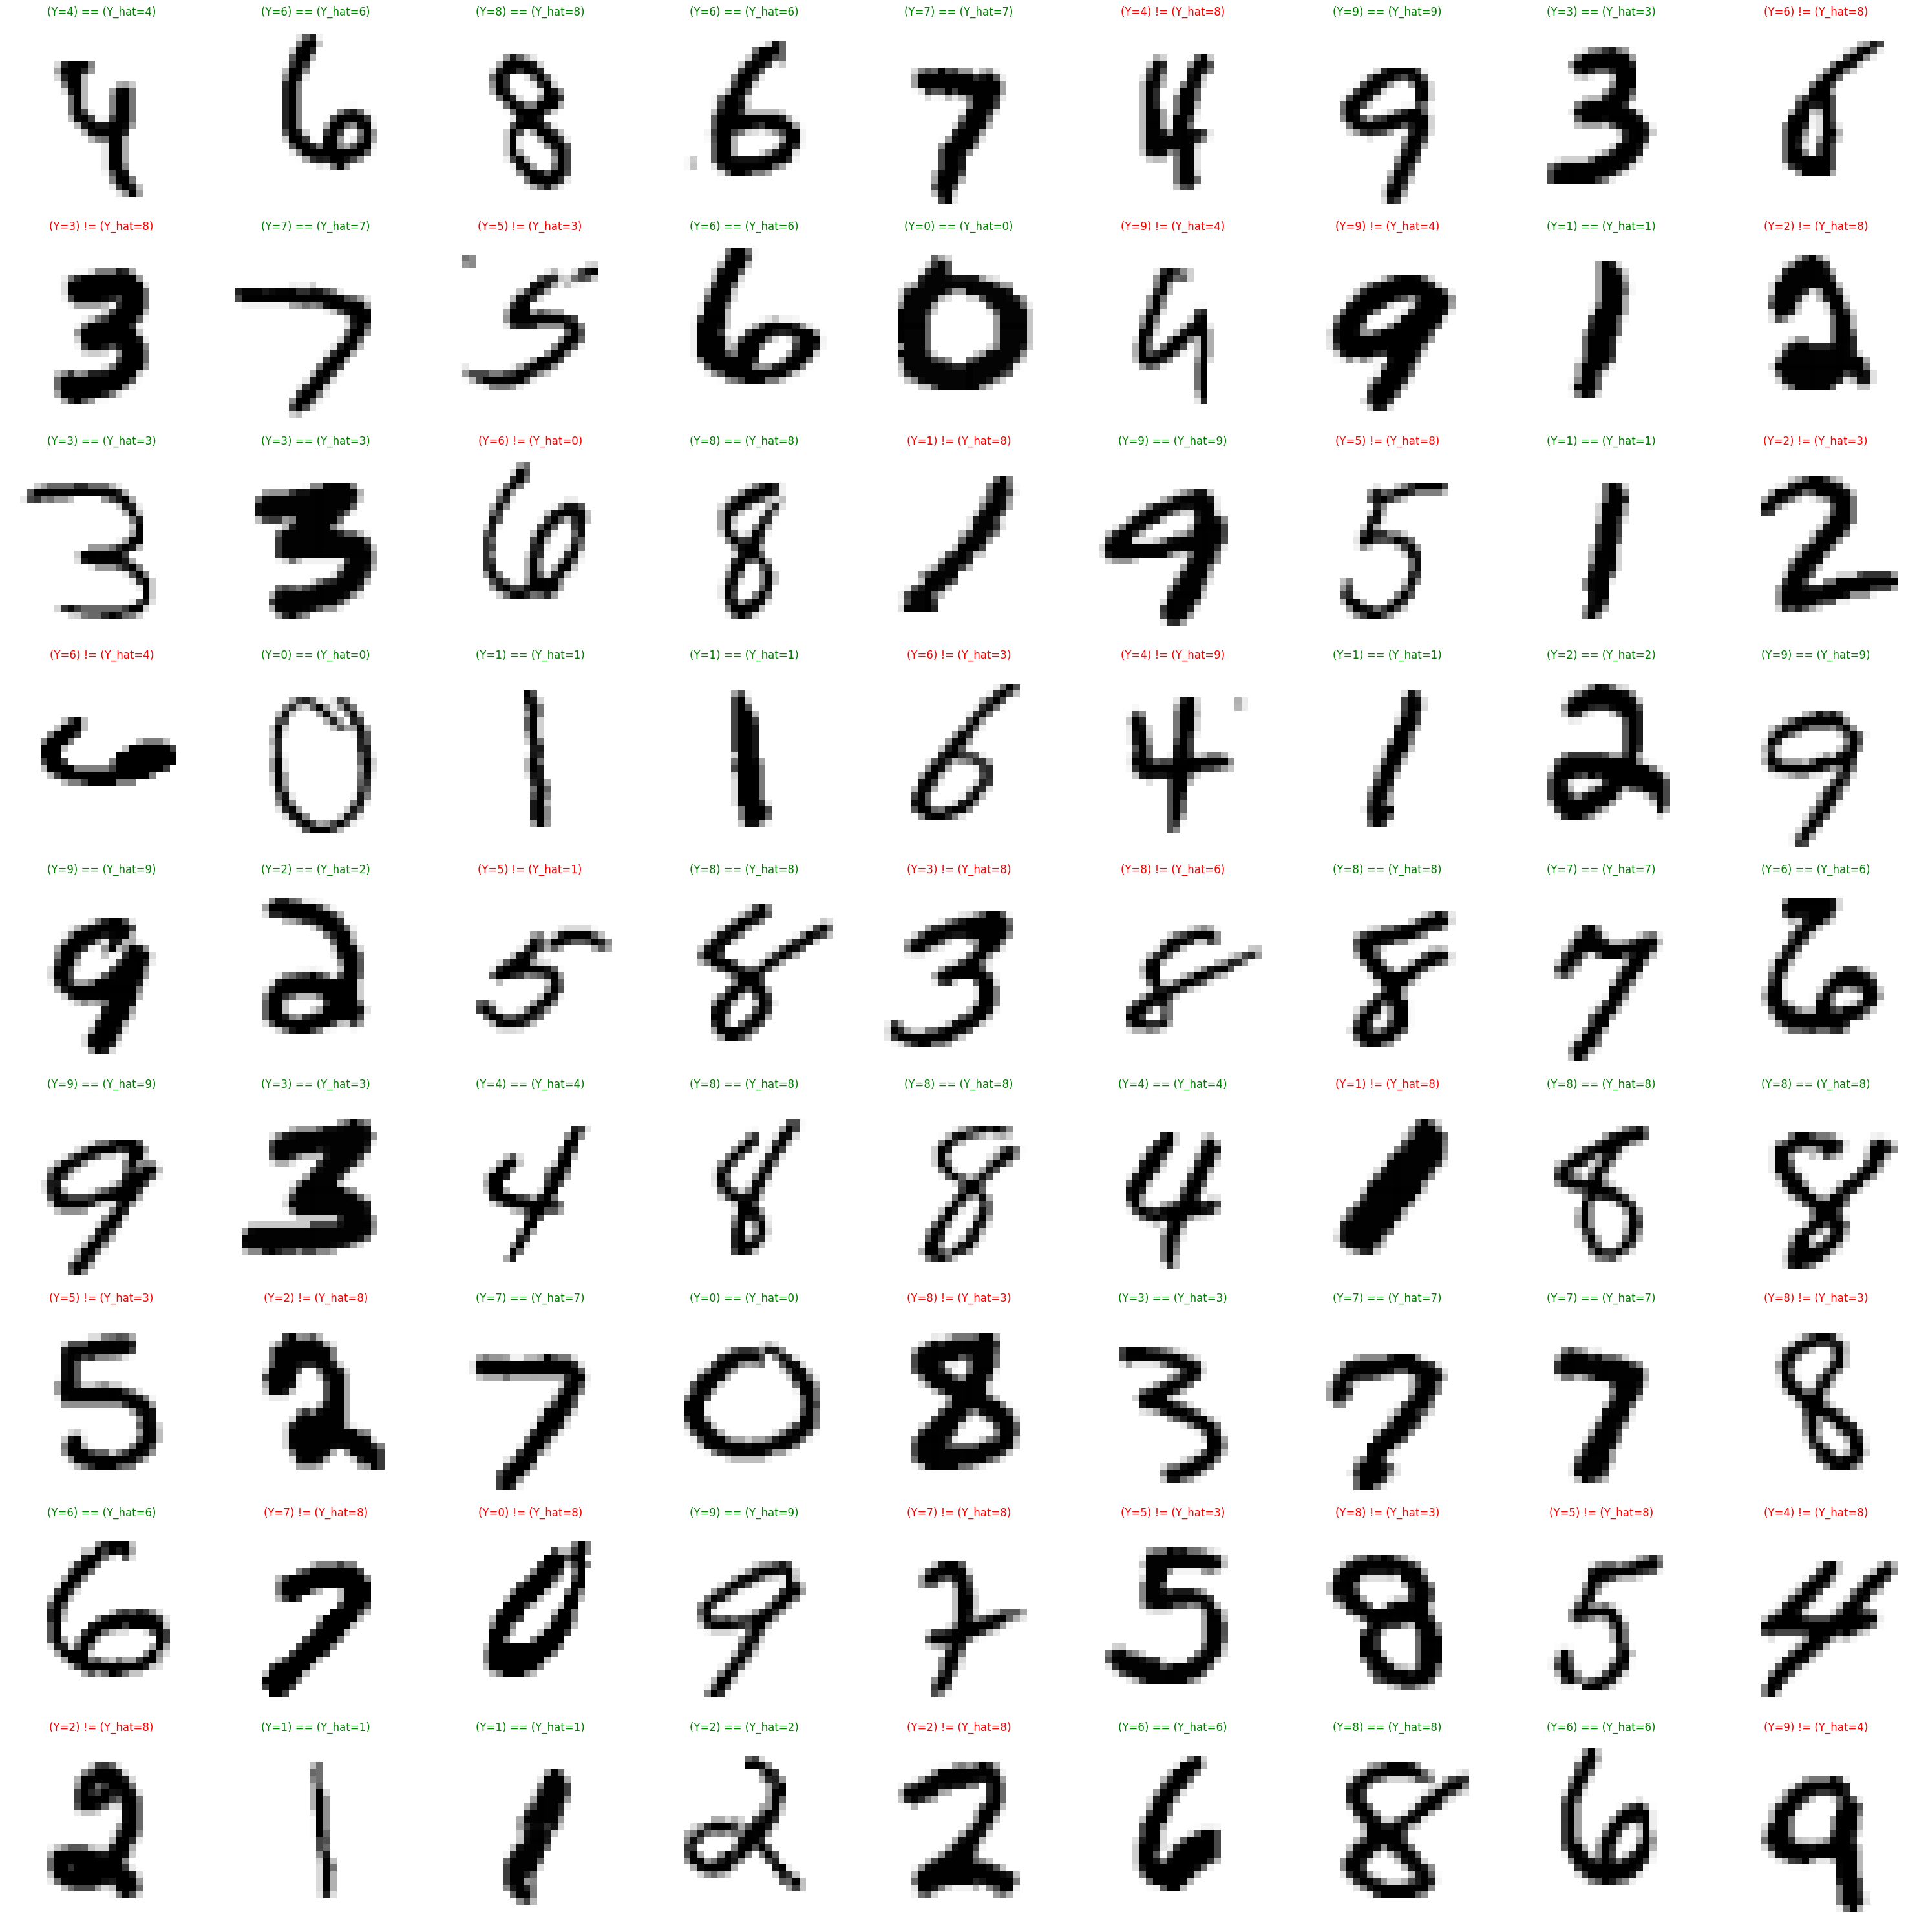

In [11]:
import math
import matplotlib.pyplot as plt

_best_checkpoints = [c for c in NNRun.load("best").checkpoints() if c is not None]
model = NNModel.from_checkpoint(checkpoint=_best_checkpoints[-1])

test_batch = next(iter(ds.test_loader))
test_X, test_Y = model.net.unpack_batch(test_batch)
test_X, test_Y = tuple(x.numpy() for x in test_X), test_Y.numpy()
test_Y_hat = model.predict(X=test_X)

N_SAMPLES = 81
_, axes = plt.subplots(
    figsize=(30, 30)
    , nrows=int(math.sqrt(N_SAMPLES))
    , ncols=int(math.sqrt(N_SAMPLES))
)
axes = axes.ravel()

for ax, X, Y, Y_hat in zip(axes, test_X[0][:N_SAMPLES], test_Y[:N_SAMPLES], test_Y_hat[1][:N_SAMPLES]):
    ax.set_axis_off()
    ax.imshow(X.reshape(28, 28), cmap=plt.cm.gray_r, interpolation="nearest")

    ax.set_title(
        f"(Y={Y}) {'==' if Y_hat == Y else '!='} (Y_hat={Y_hat})"
        , color="green" if Y_hat == Y else "red"
    )

plt.tight_layout()
plt.show()